# Week 6 — SHAP Integration
### Explainability Layer for the Credit Risk Framework
---
**Goal:** Make the best model from Week 5 explain itself — globally and locally.

For each dataset (German Credit · LendingClub · Credit Card Fraud) we will:
1. Load the best trained model + test data using the Week 5 registry
2. Build the right SHAP explainer for the model type
3. Compute **global** explanations — what the model has learned overall (beeswarm, bar, dependence)
4. Compute **local** explanations — why specific decisions were made (waterfall, force)
5. Validate top features against credit-risk theory
6. Save SHAP values to Drive for Weeks 7, 8, and 9

> **Run order:** Cell 1 (mount) → Cell 2 (install) → Cell 3 (paths) → Cell 4 (helpers) → Run All

## Cell 1 — Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
print("Drive mounted.")

Mounted at /content/drive
Drive mounted.


## Cell 2 — Install Dependencies

In [2]:
!pip install -q shap==0.46.0 xgboost==2.1.1 mlflow==2.16.2 pyarrow==16.1.0
print("Dependencies installed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 543.9/543.9 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.9/153.9 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 83.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 879.5/879.5 kB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 12.9 MB/s eta 0:00:00
Dependencies installed.


## Cell 3 — Imports & Paths

In [3]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option('display.max_columns', None)
plt.rcParams['figure.dpi'] = 110

# ── Same root as Weeks 4 & 5 ─────────────────────────────────────────
WK4_ROOT     = '/content/drive/MyDrive/CreditRisk_Wk4'
PROCESSED    = f'{WK4_ROOT}/processed'
MODELS_DIR   = f'{WK4_ROOT}/models'
REGISTRY     = f'{WK4_ROOT}/best_models_registry.json'

# ── Week 6 outputs ───────────────────────────────────────────────────
WK6_ROOT     = '/content/drive/MyDrive/CreditRisk_Wk6'
SHAP_DIR     = f'{WK6_ROOT}/shap_values'
FIGURES_DIR  = f'{WK6_ROOT}/figures'
os.makedirs(SHAP_DIR,    exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print(f'Week 4/5 root : {WK4_ROOT}')
print(f'Models dir    : {MODELS_DIR}')
print(f'Week 6 outputs: {WK6_ROOT}')
print(f'SHAP version  : {shap.__version__}')

# Verify registry exists
if not os.path.exists(REGISTRY):
    raise FileNotFoundError(
        f'Registry not found: {REGISTRY}\n'
        'Re-run Week 5 — its final cell writes best_models_registry.json'
    )
with open(REGISTRY) as f:
    BEST = json.load(f)
print('\nBest models from Week 5:')
for ds, info in BEST.items():
    print(f'  {ds:13s} → {info["model_name"]:20s} (test AUC={info["test_roc_auc"]:.4f})')

Week 4/5 root : /content/drive/MyDrive/CreditRisk_Wk4
Models dir    : /content/drive/MyDrive/CreditRisk_Wk4/models
Week 6 outputs: /content/drive/MyDrive/CreditRisk_Wk6
SHAP version  : 0.46.0

Best models from Week 5:
  german        → Logistic Regression  (test AUC=0.7966)
  lendingclub   → XGBoost              (test AUC=0.7123)
  fraud         → XGBoost              (test AUC=0.9825)


## Cell 4 — Helpers
Defines:
- `load_splits()` — loads parquet test data (matches Week 5 exactly)
- `make_explainer()` — picks the right SHAP explainer for the model type
- `save_fig()` — saves figures to the Week 6 figures folder
- `compute_shap_values()` — handles sampling for large datasets to keep runtime reasonable

In [4]:
def load_splits(dataset_name):
    base = f'{PROCESSED}/{dataset_name}'
    X_train = pd.read_parquet(f'{base}/X_train.parquet')
    X_val   = pd.read_parquet(f'{base}/X_val.parquet')
    X_test  = pd.read_parquet(f'{base}/X_test.parquet')
    y_train = pd.read_parquet(f'{base}/y_train.parquet')['target']
    y_val   = pd.read_parquet(f'{base}/y_val.parquet')['target']
    y_test  = pd.read_parquet(f'{base}/y_test.parquet')['target']
    return X_train, X_val, X_test, y_train, y_val, y_test


def load_best_model(dataset_key):
    """Load model + return (model, model_name, model_tag)."""
    info  = BEST[dataset_key]
    model = joblib.load(info['model_path'])
    name  = info['model_name']
    tag   = {'Logistic Regression':'logreg', 'Random Forest':'rf', 'XGBoost':'xgb'}[name]
    print(f'[{dataset_key}] loaded {name} from {info["model_path"]}')
    return model, name, tag


def make_explainer(model, model_name, X_background):
    """Pick the right SHAP explainer for the model type."""
    if model_name == 'Logistic Regression':
        # LinearExplainer needs a background distribution (sample of training data)
        return shap.LinearExplainer(model, X_background)
    elif model_name in ('Random Forest', 'XGBoost'):
        # TreeExplainer is fast and exact for tree models
        return shap.TreeExplainer(model)
    else:
        return shap.KernelExplainer(model.predict_proba, X_background)


def compute_shap_values(explainer, X, model_name, max_rows=2000):
    """Compute SHAP values, sampling X if too large to keep runtime reasonable."""
    if len(X) > max_rows:
        X_sample = X.sample(n=max_rows, random_state=RANDOM_STATE)
        print(f'  Sampling {max_rows} of {len(X)} rows for SHAP computation')
    else:
        X_sample = X
        print(f'  Computing SHAP on all {len(X)} rows')

    sv = explainer.shap_values(X_sample)

    # TreeExplainer on a binary classifier returns a list [class0, class1]
    # in older shap versions, or an array of shape (n, features, 2) in newer.
    # We always want the positive-class (class 1) values.
    if isinstance(sv, list) and len(sv) == 2:
        sv = sv[1]
    elif isinstance(sv, np.ndarray) and sv.ndim == 3:
        sv = sv[:, :, 1]
    return sv, X_sample


def save_fig(name):
    path = f'{FIGURES_DIR}/{name}.png'
    plt.savefig(path, bbox_inches='tight', dpi=130)
    print(f'  Saved → {path}')


def pick_representative_cases(model, X, y, n_per_kind=1):
    """Return indices for: clear approval, clear rejection, borderline case."""
    probs = model.predict_proba(X)[:, 1]  # P(class=1)

    # Clearest "good" case: lowest probability of being bad/default/fraud
    clear_good = np.argsort(probs)[:n_per_kind].tolist()
    # Clearest "bad" case: highest probability of being bad/default/fraud
    clear_bad  = np.argsort(probs)[-n_per_kind:][::-1].tolist()
    # Borderline: closest to 0.5
    borderline = np.argsort(np.abs(probs - 0.5))[:n_per_kind].tolist()

    return {
        'clear_approval' : clear_good,
        'clear_rejection': clear_bad,
        'borderline'     : borderline,
    }


print('Helpers ready.')

Helpers ready.


---
# 1 — German Credit

## 1.1 Load Best Model & Data

In [5]:
X_tr1, X_va1, X_te1, y_tr1, y_va1, y_te1 = load_splits('german')
model_g, name_g, tag_g = load_best_model('german')

# Sanity check: predictions still match what Week 5 reported
from sklearn.metrics import roc_auc_score
auc_check = roc_auc_score(y_te1, model_g.predict_proba(X_te1)[:,1])
print(f'\n[sanity] test AUC: {auc_check:.4f}  (Week 5 registry: {BEST["german"]["test_roc_auc"]:.4f})')

[german] loaded Logistic Regression from /content/drive/MyDrive/CreditRisk_Wk4/models/german_logreg.joblib

[sanity] test AUC: 0.7966  (Week 5 registry: 0.7966)


## 1.2 Build SHAP Explainer & Compute Values
The German Credit test set is small (~200 rows), so we compute SHAP on the
entire test set.

In [6]:
# Use a sample of training data as the background distribution for LinearExplainer
# (TreeExplainer ignores the background param)
bg_g = shap.sample(X_tr1, 100, random_state=RANDOM_STATE)
explainer_g = make_explainer(model_g, name_g, bg_g)

shap_vals_g, X_g_sample = compute_shap_values(explainer_g, X_te1, name_g, max_rows=2000)
print(f'  shap_values shape: {shap_vals_g.shape}')

  Computing SHAP on all 150 rows
  shap_values shape: (150, 60)


## 1.3 Global Explanations — German Credit
**Beeswarm plot:** each dot is a customer; x-axis is the feature's SHAP value
(positive pushes prediction toward "bad credit", negative toward "good credit");
colour shows the feature's actual value (red = high, blue = low).

  Saved → /content/drive/MyDrive/CreditRisk_Wk6/figures/german_beeswarm.png


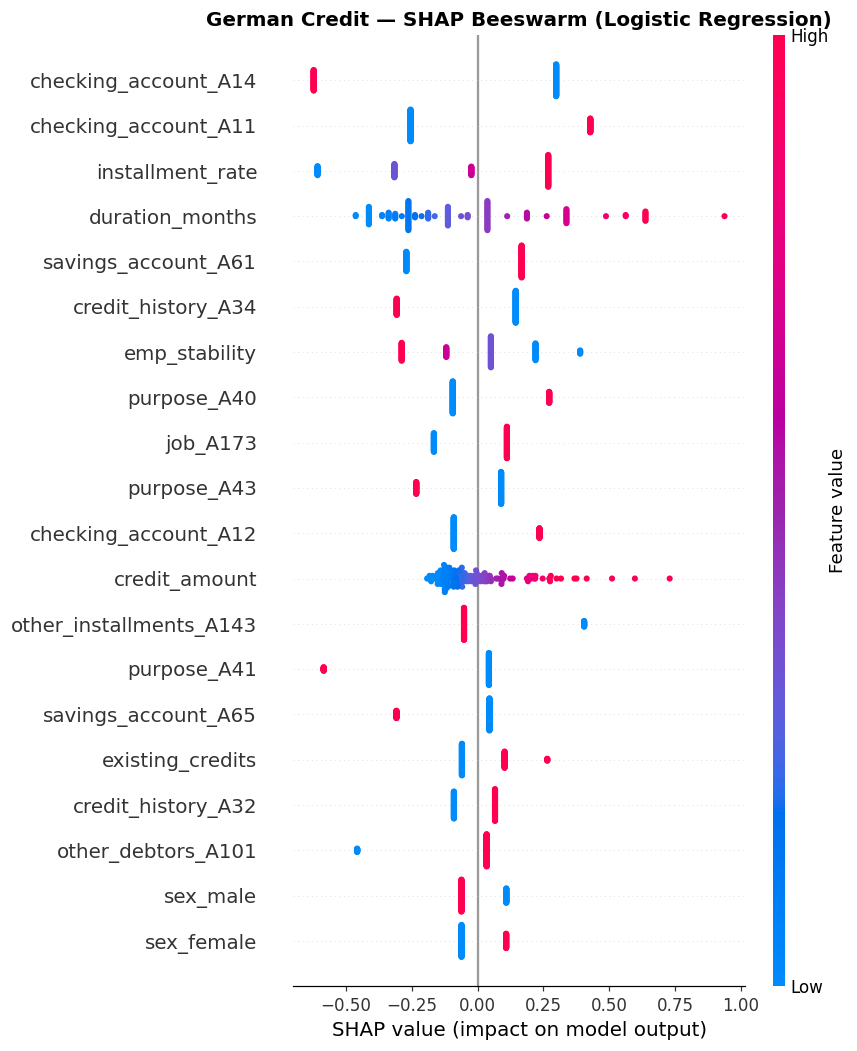

In [7]:
shap.summary_plot(shap_vals_g, X_g_sample, max_display=20, show=False)
plt.title(f'German Credit — SHAP Beeswarm ({name_g})', fontsize=13, weight='bold')
save_fig('german_beeswarm')
plt.show()

**Bar plot:** mean absolute SHAP value per feature — cleaner ranking of overall importance.

  Saved → /content/drive/MyDrive/CreditRisk_Wk6/figures/german_bar.png


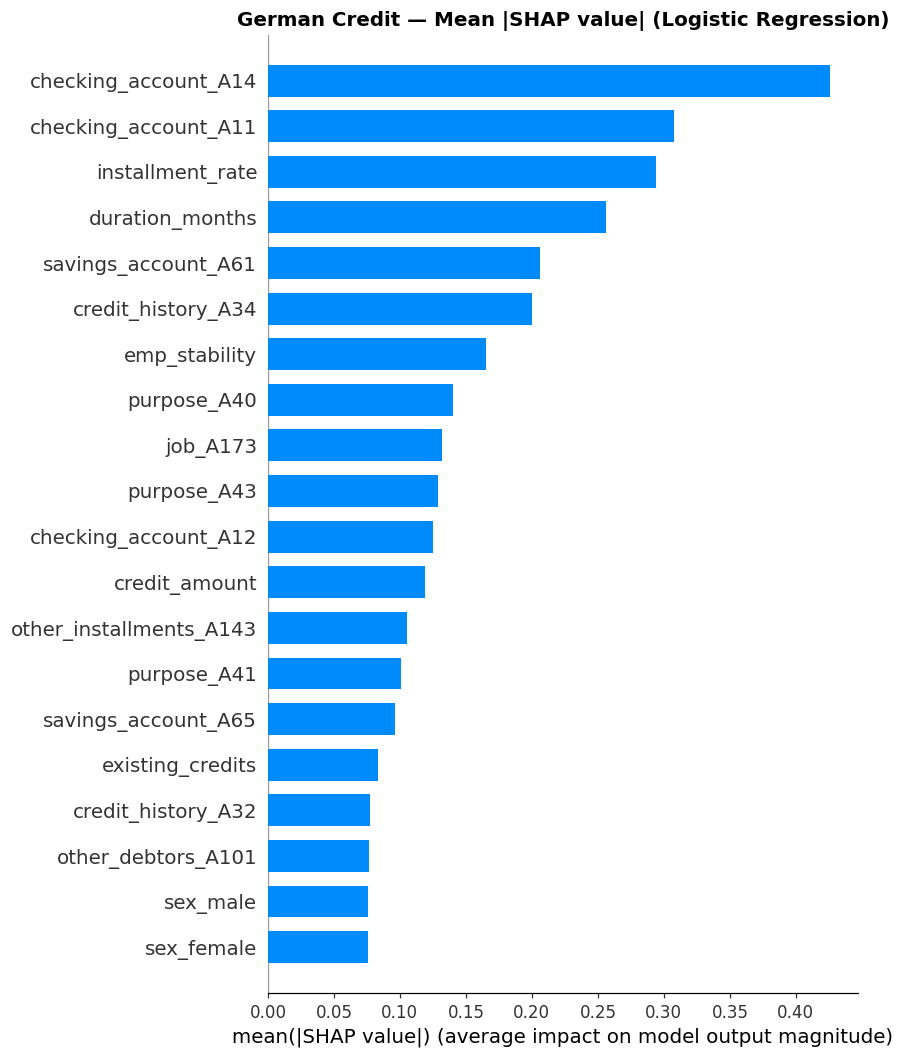

In [8]:
shap.summary_plot(shap_vals_g, X_g_sample, plot_type='bar', max_display=20, show=False)
plt.title(f'German Credit — Mean |SHAP value| ({name_g})', fontsize=13, weight='bold')
save_fig('german_bar')
plt.show()

**Dependence plots** for the top 5 features. Each plot shows how the feature's
value (x-axis) affects its SHAP contribution (y-axis). Look for thresholds
and non-linearities — these are insights you can write up in the dissertation.

Top 5 features (German): ['checking_account_A14', 'checking_account_A11', 'installment_rate', 'duration_months', 'savings_account_A61']
  Saved → /content/drive/MyDrive/CreditRisk_Wk6/figures/german_dependence_top5.png


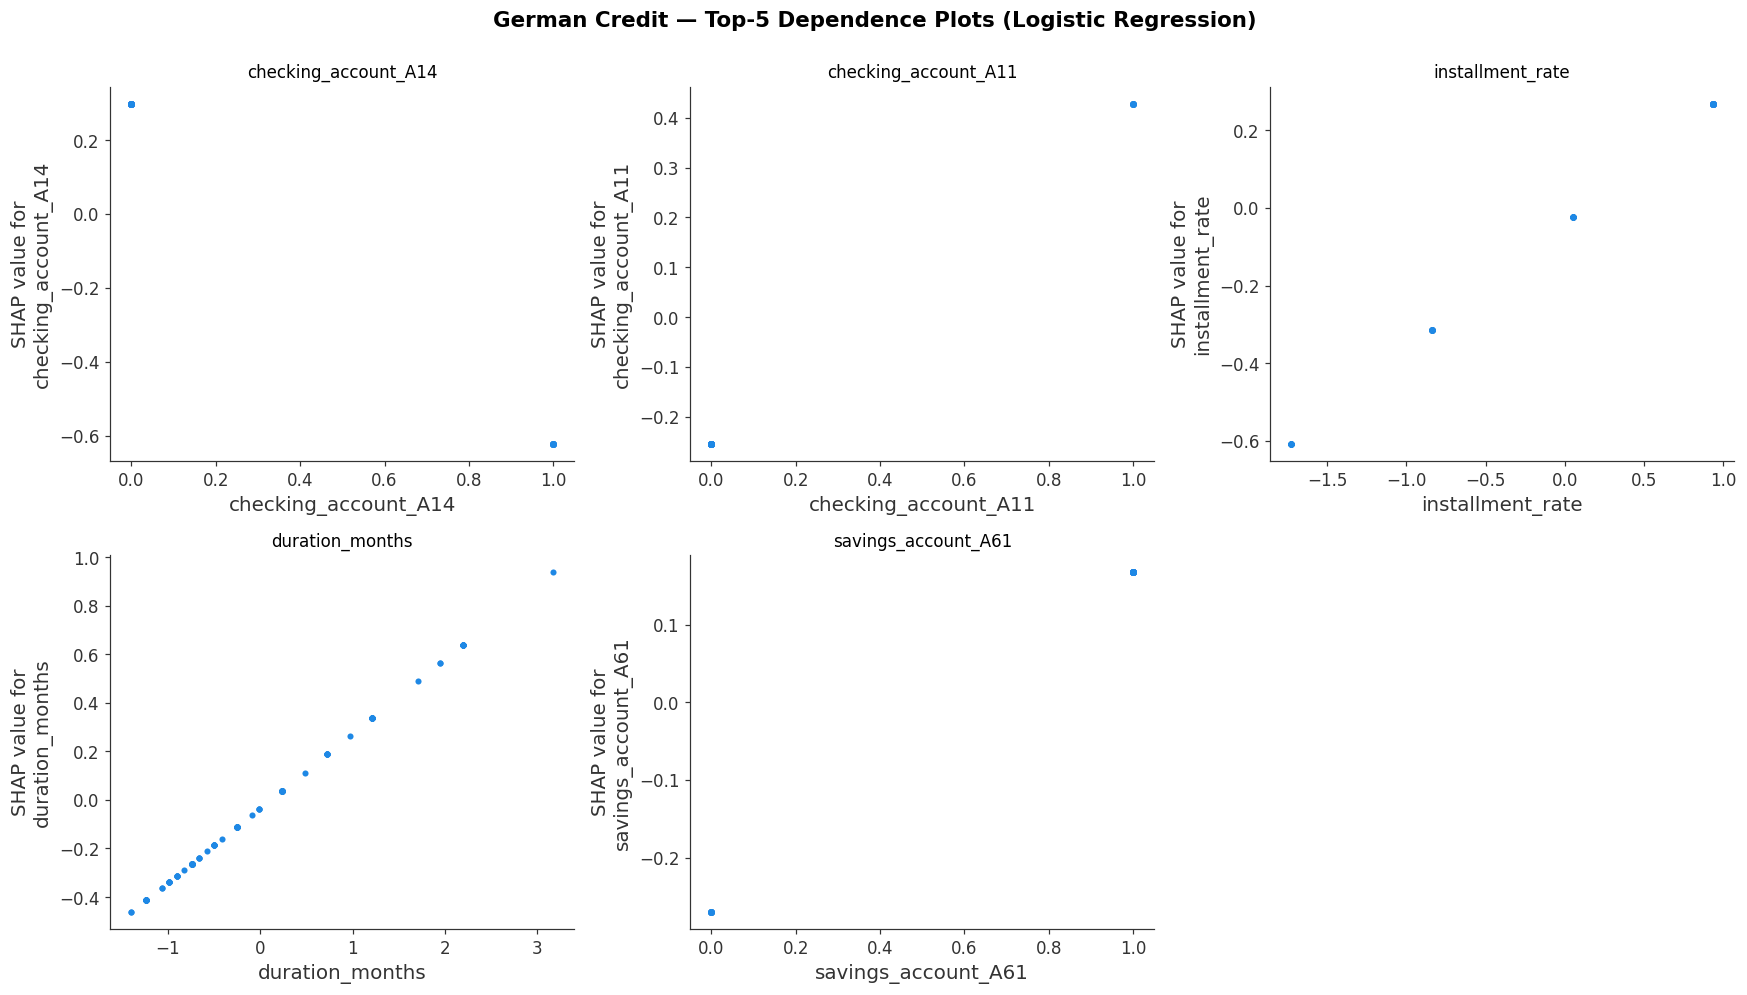

In [9]:
# Find top-5 features by mean |SHAP|
mean_abs_g = pd.Series(np.abs(shap_vals_g).mean(axis=0), index=X_g_sample.columns)
top5_g = mean_abs_g.nlargest(5).index.tolist()
print(f'Top 5 features (German): {top5_g}')

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, feat in enumerate(top5_g):
    shap.dependence_plot(feat, shap_vals_g, X_g_sample,
                         ax=axes[i], show=False, interaction_index=None)
    axes[i].set_title(f'{feat}', fontsize=11)
axes[5].axis('off')   # blank 6th slot
plt.suptitle(f'German Credit — Top-5 Dependence Plots ({name_g})',
             fontsize=14, weight='bold', y=1.00)
plt.tight_layout()
save_fig('german_dependence_top5')
plt.show()

## 1.4 Local Explanations — German Credit
Pick three representative cases and show **why** the model decided what it did.
- **Clear approval** — the lowest-probability case (most confidently good)
- **Clear rejection** — the highest-probability case (most confidently bad)
- **Borderline** — closest to 0.5 (where explanations matter most)

In [10]:
# Reset index of test set to align with positional indices used by SHAP
X_te1_idx = X_te1.reset_index(drop=True)
y_te1_idx = y_te1.reset_index(drop=True)

# Recompute SHAP on full test set with reset index for selecting cases
sv_g_full, _ = compute_shap_values(explainer_g, X_te1_idx, name_g, max_rows=10_000)

cases_g = pick_representative_cases(model_g, X_te1_idx, y_te1_idx, n_per_kind=1)
print('Selected cases (positional index in test set):')
for kind, idxs in cases_g.items():
    for idx in idxs:
        prob = model_g.predict_proba(X_te1_idx.iloc[[idx]])[0, 1]
        actual = y_te1_idx.iloc[idx]
        print(f'  {kind:18s} idx={idx:3d}  P(bad)={prob:.3f}  actual={actual}')

  Computing SHAP on all 150 rows
Selected cases (positional index in test set):
  clear_approval     idx= 80  P(bad)=0.030  actual=0
  clear_rejection    idx=148  P(bad)=0.929  actual=0
  borderline         idx= 21  P(bad)=0.495  actual=0


**Waterfall plots** — show the path from the model's base value to the prediction for each case.

  Saved → /content/drive/MyDrive/CreditRisk_Wk6/figures/german_waterfall_clear_approval_80.png


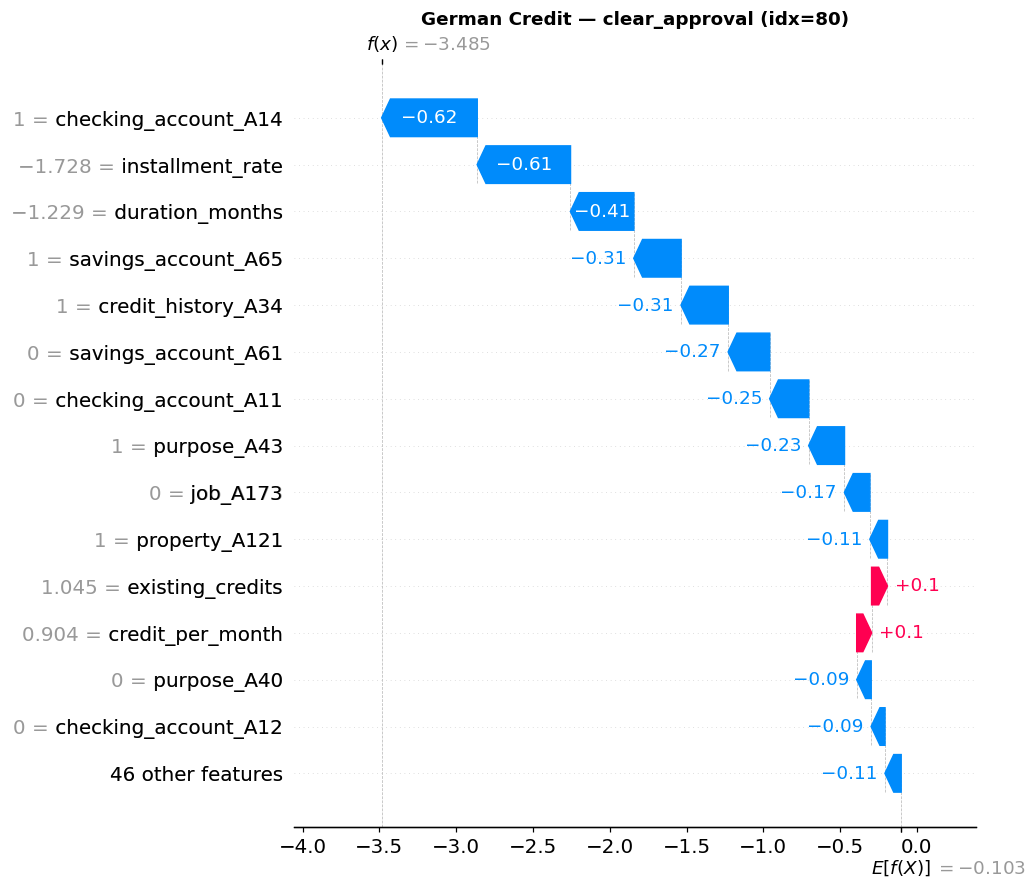

  Saved → /content/drive/MyDrive/CreditRisk_Wk6/figures/german_waterfall_clear_rejection_148.png


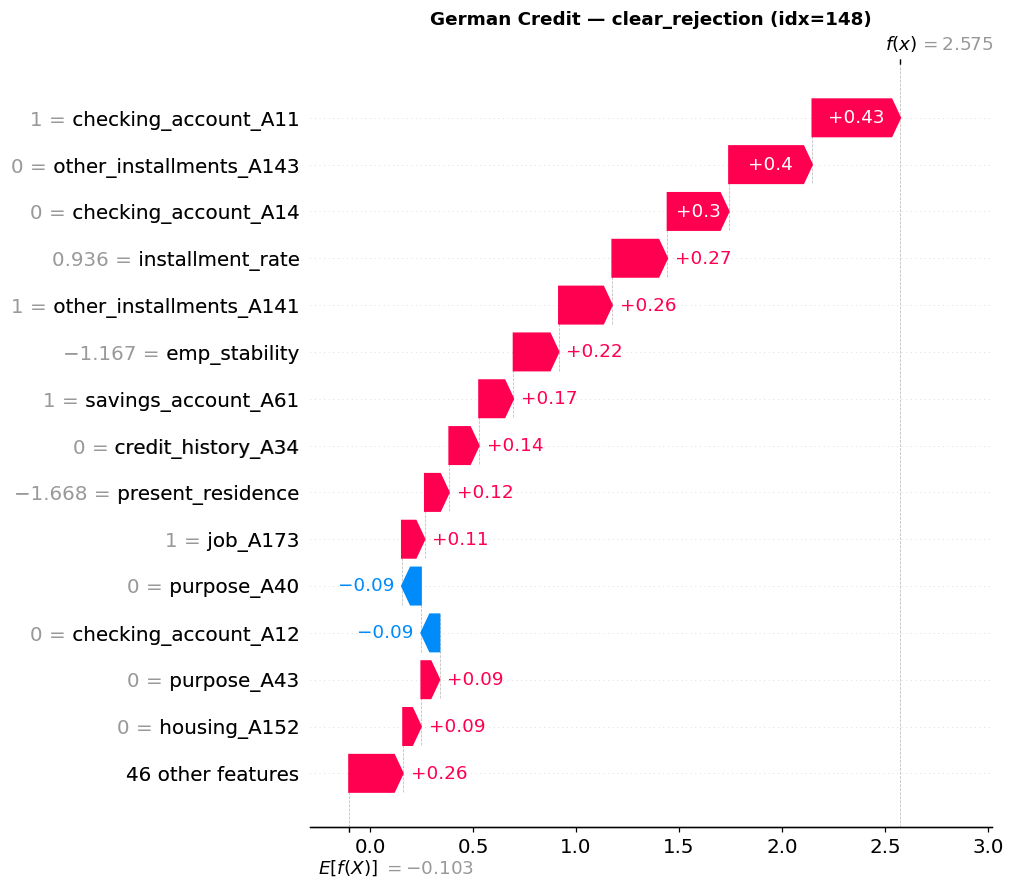

  Saved → /content/drive/MyDrive/CreditRisk_Wk6/figures/german_waterfall_borderline_21.png


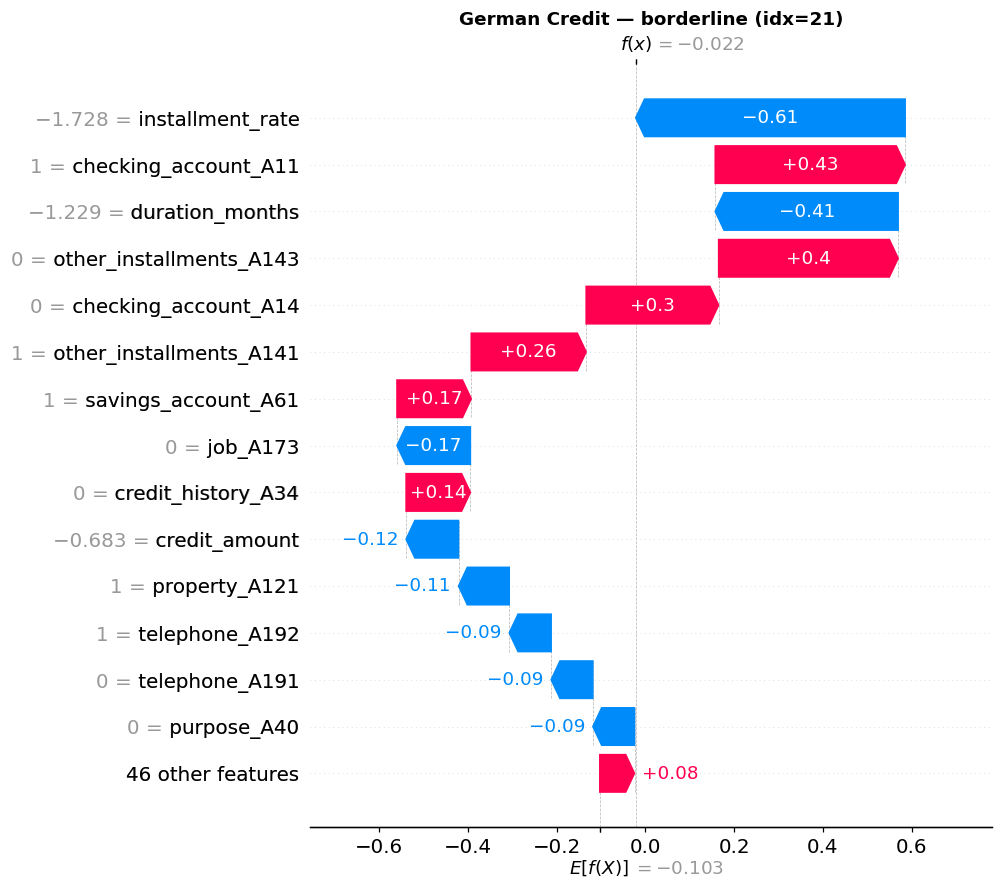

In [11]:
def waterfall_for(idx, kind, sv, X, expl, model_name):
    if model_name == 'Logistic Regression':
        ev = float(np.array(expl.expected_value).flatten()[0])
    else:
        ev_arr = np.array(expl.expected_value).flatten()
        ev = float(ev_arr[1] if len(ev_arr) > 1 else ev_arr[0])

    explanation = shap.Explanation(
        values        = sv[idx],
        base_values   = ev,
        data          = X.iloc[idx].values,
        feature_names = X.columns.tolist()
    )
    shap.plots.waterfall(explanation, max_display=15, show=False)
    plt.title(f'German Credit — {kind} (idx={idx})', fontsize=12, weight='bold')

for kind, idxs in cases_g.items():
    for idx in idxs:
        plt.figure()
        waterfall_for(idx, kind, sv_g_full, X_te1_idx, explainer_g, name_g)
        save_fig(f'german_waterfall_{kind}_{idx}')
        plt.show()

## 1.5 Domain Validation — Do the Top Features Match Credit-Risk Theory?

In [12]:
print('═══ German Credit — Top 10 Features by Mean |SHAP| ═══\n')
top10_g = mean_abs_g.nlargest(10)
for rank, (feat, val) in enumerate(top10_g.items(), 1):
    print(f'  {rank:2d}. {feat:40s} {val:.4f}')

print('\n📋 Domain check (fill in during dissertation write-up):')
print('   - Does checking_account_status appear high?  Expected: YES (key risk signal)')
print('   - Does duration_months appear high?           Expected: YES (longer = riskier)')
print('   - Does credit_history appear high?            Expected: YES')
print('   - Any counterintuitive features at the top?   FLAG FOR DISCUSSION')

═══ German Credit — Top 10 Features by Mean |SHAP| ═══

   1. checking_account_A14                     0.4258
   2. checking_account_A11                     0.3076
   3. installment_rate                         0.2938
   4. duration_months                          0.2560
   5. savings_account_A61                      0.2065
   6. credit_history_A34                       0.2000
   7. emp_stability                            0.1651
   8. purpose_A40                              0.1402
   9. job_A173                                 0.1318
  10. purpose_A43                              0.1286

📋 Domain check (fill in during dissertation write-up):
   - Does checking_account_status appear high?  Expected: YES (key risk signal)
   - Does duration_months appear high?           Expected: YES (longer = riskier)
   - Does credit_history appear high?            Expected: YES
   - Any counterintuitive features at the top?   FLAG FOR DISCUSSION


## 1.6 Save SHAP Values for Weeks 7-9

In [13]:
out_g = f'{SHAP_DIR}/german_shap.joblib'
joblib.dump({
    'shap_values_full' : sv_g_full,         # full test set, for dashboard
    'shap_values_sample': shap_vals_g,      # sampled (== full here for German)
    'X_sample'         : X_g_sample,
    'X_test'           : X_te1_idx,
    'y_test'           : y_te1_idx,
    'expected_value'   : explainer_g.expected_value,
    'feature_names'    : X_te1.columns.tolist(),
    'model_name'       : name_g,
    'top_features'     : top10_g.to_dict(),
    'representative_cases': cases_g,
}, out_g)
print(f'Saved → {out_g}  ({os.path.getsize(out_g)/1024:.1f} KB)')

Saved → /content/drive/MyDrive/CreditRisk_Wk6/shap_values/german_shap.joblib  (288.8 KB)


---
# 2 — LendingClub

## 2.1 Load Best Model & Data

In [14]:
X_tr2, X_va2, X_te2, y_tr2, y_va2, y_te2 = load_splits('lendingclub')
model_lc, name_lc, tag_lc = load_best_model('lendingclub')

from sklearn.metrics import roc_auc_score
auc_check = roc_auc_score(y_te2, model_lc.predict_proba(X_te2)[:,1])
print(f'\n[sanity] test AUC: {auc_check:.4f}  (Week 5 registry: {BEST["lendingclub"]["test_roc_auc"]:.4f})')

[lendingclub] loaded XGBoost from /content/drive/MyDrive/CreditRisk_Wk4/models/lendingclub_xgb.joblib

[sanity] test AUC: 0.7123  (Week 5 registry: 0.7123)


## 2.2 Build SHAP Explainer & Compute Values
LendingClub is large — we sample 2,000 rows for SHAP. This keeps runtime under
~5 minutes for tree models, ~2 minutes for logistic regression.

In [15]:
bg_lc = shap.sample(X_tr2, 100, random_state=RANDOM_STATE)
explainer_lc = make_explainer(model_lc, name_lc, bg_lc)

shap_vals_lc, X_lc_sample = compute_shap_values(explainer_lc, X_te2, name_lc, max_rows=2000)
print(f'  shap_values shape: {shap_vals_lc.shape}')

  Sampling 2000 of 22500 rows for SHAP computation
  shap_values shape: (2000, 100)


## 2.3 Global Explanations — LendingClub

  Saved → /content/drive/MyDrive/CreditRisk_Wk6/figures/lendingclub_beeswarm.png


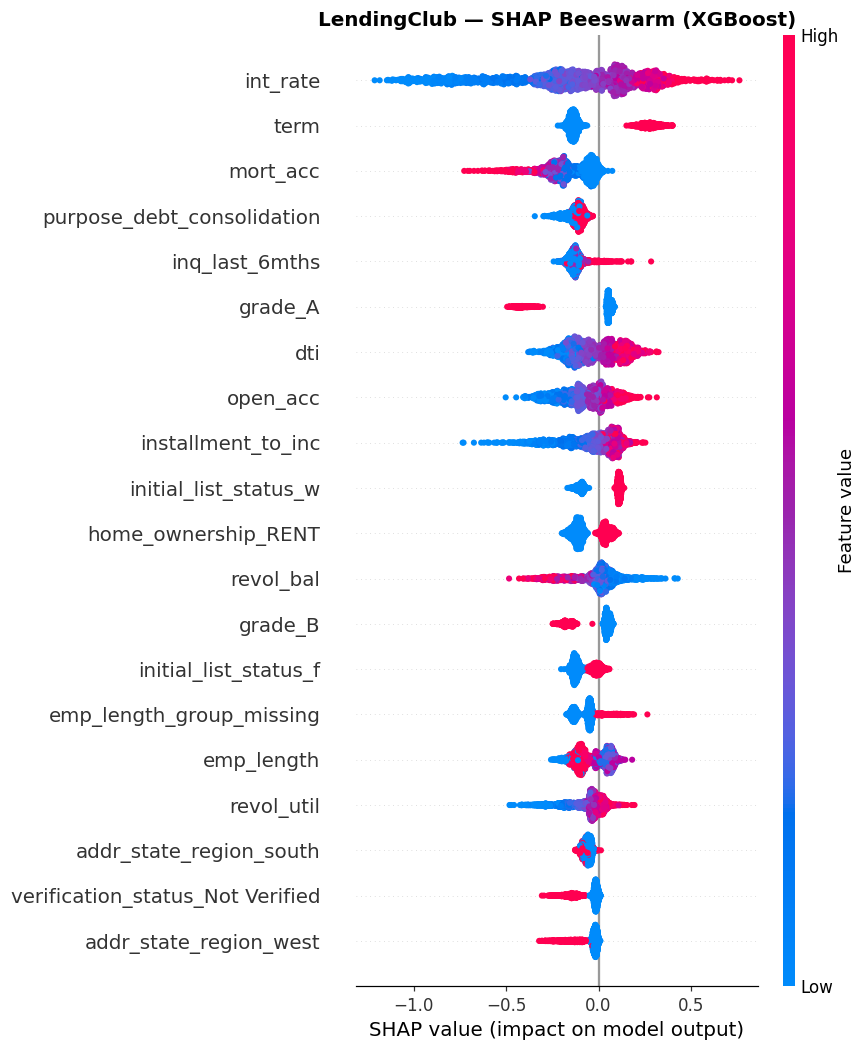

In [16]:
shap.summary_plot(shap_vals_lc, X_lc_sample, max_display=20, show=False)
plt.title(f'LendingClub — SHAP Beeswarm ({name_lc})', fontsize=13, weight='bold')
save_fig('lendingclub_beeswarm')
plt.show()

  Saved → /content/drive/MyDrive/CreditRisk_Wk6/figures/lendingclub_bar.png


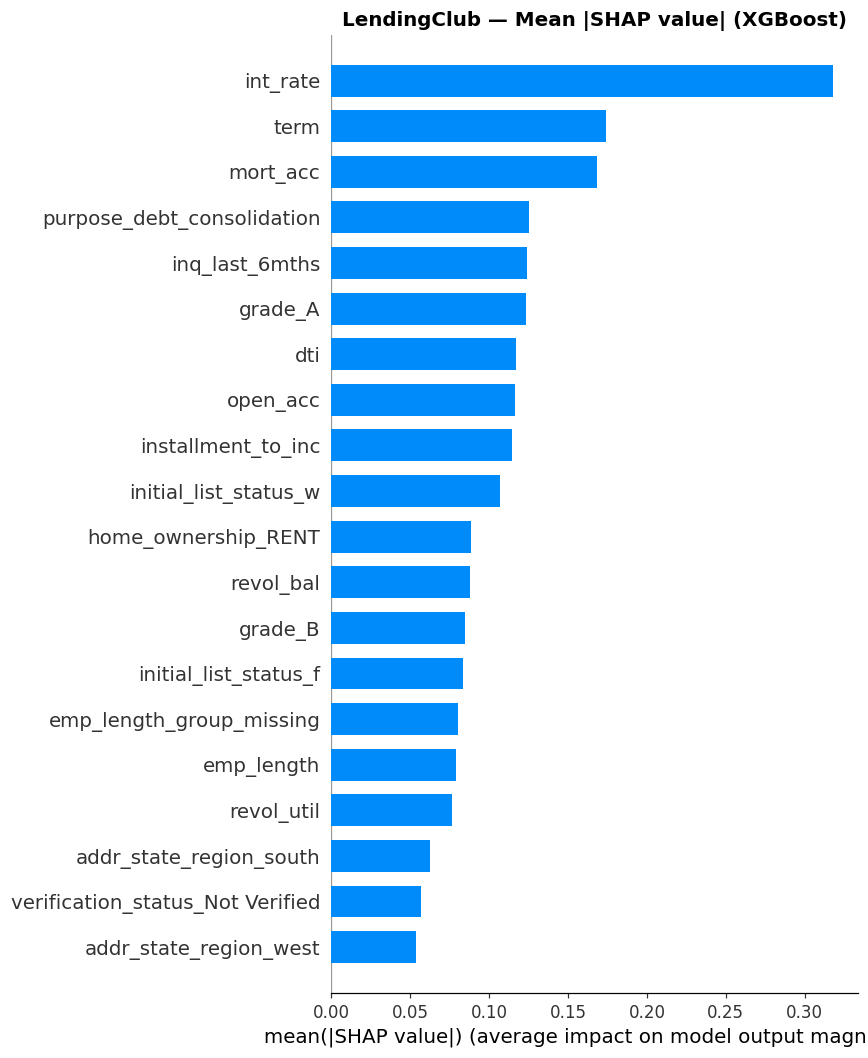

In [17]:
shap.summary_plot(shap_vals_lc, X_lc_sample, plot_type='bar', max_display=20, show=False)
plt.title(f'LendingClub — Mean |SHAP value| ({name_lc})', fontsize=13, weight='bold')
save_fig('lendingclub_bar')
plt.show()

Top 5 features (LendingClub): ['int_rate', 'term', 'mort_acc', 'purpose_debt_consolidation', 'inq_last_6mths']
  Saved → /content/drive/MyDrive/CreditRisk_Wk6/figures/lendingclub_dependence_top5.png


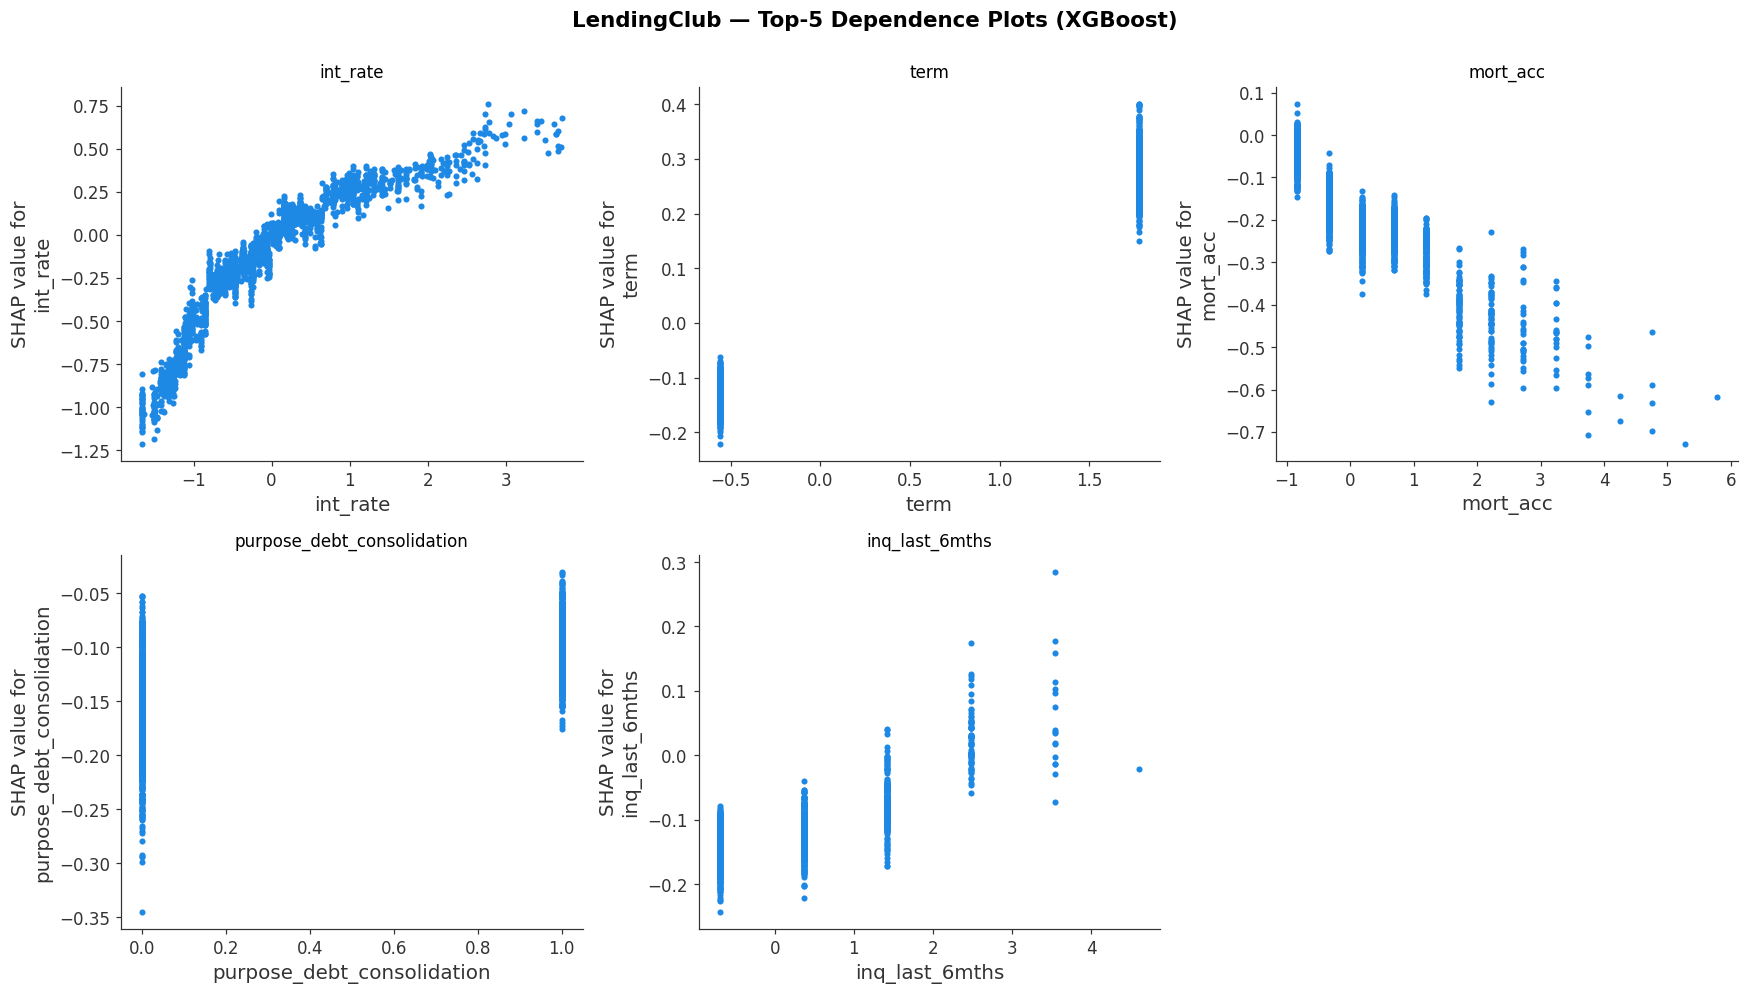

In [18]:
mean_abs_lc = pd.Series(np.abs(shap_vals_lc).mean(axis=0), index=X_lc_sample.columns)
top5_lc = mean_abs_lc.nlargest(5).index.tolist()
print(f'Top 5 features (LendingClub): {top5_lc}')

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, feat in enumerate(top5_lc):
    shap.dependence_plot(feat, shap_vals_lc, X_lc_sample,
                         ax=axes[i], show=False, interaction_index=None)
    axes[i].set_title(f'{feat}', fontsize=11)
axes[5].axis('off')
plt.suptitle(f'LendingClub — Top-5 Dependence Plots ({name_lc})',
             fontsize=14, weight='bold', y=1.00)
plt.tight_layout()
save_fig('lendingclub_dependence_top5')
plt.show()

## 2.4 Local Explanations — LendingClub

In [20]:
# For local explanations on LendingClub we sample 5000 rows so we have
# enough variety to find clear cases without computing SHAP on the full set.
# Use positional sampling so X and y stay aligned regardless of original indices.
sample_size = min(5000, len(X_te2))
rng = np.random.default_rng(RANDOM_STATE)
sample_pos = rng.choice(len(X_te2), size=sample_size, replace=False)

X_te2_sample = X_te2.iloc[sample_pos].reset_index(drop=True)
y_te2_sample = y_te2.iloc[sample_pos].reset_index(drop=True)

print(f'Sampled {sample_size} rows  '
      f'(default rate in sample: {y_te2_sample.mean():.3f})')

sv_lc_full, _ = compute_shap_values(explainer_lc, X_te2_sample, name_lc, max_rows=sample_size)
cases_lc = pick_representative_cases(model_lc, X_te2_sample, y_te2_sample, n_per_kind=1)

print('Selected cases:')
for kind, idxs in cases_lc.items():
    for idx in idxs:
        prob = model_lc.predict_proba(X_te2_sample.iloc[[idx]])[0, 1]
        actual = y_te2_sample.iloc[idx]
        print(f'  {kind:18s} idx={idx:5d}  P(default)={prob:.3f}  actual={actual}')

Sampled 5000 rows  (default rate in sample: 0.192)
  Computing SHAP on all 5000 rows
Selected cases:
  clear_approval     idx= 3550  P(default)=0.008  actual=0
  clear_rejection    idx= 1502  P(default)=0.765  actual=0
  borderline         idx= 2550  P(default)=0.500  actual=0


  Saved → /content/drive/MyDrive/CreditRisk_Wk6/figures/lendingclub_waterfall_clear_approval_3550.png


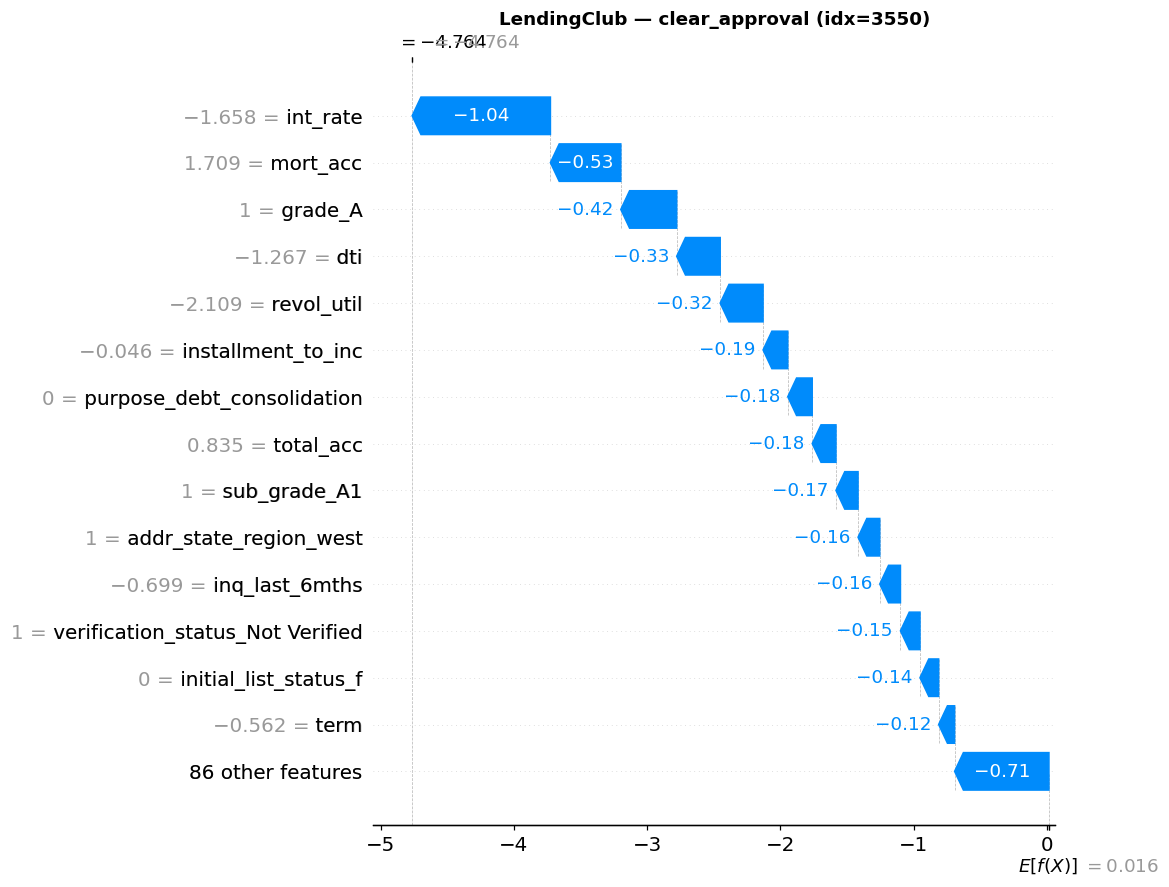

  Saved → /content/drive/MyDrive/CreditRisk_Wk6/figures/lendingclub_waterfall_clear_rejection_1502.png


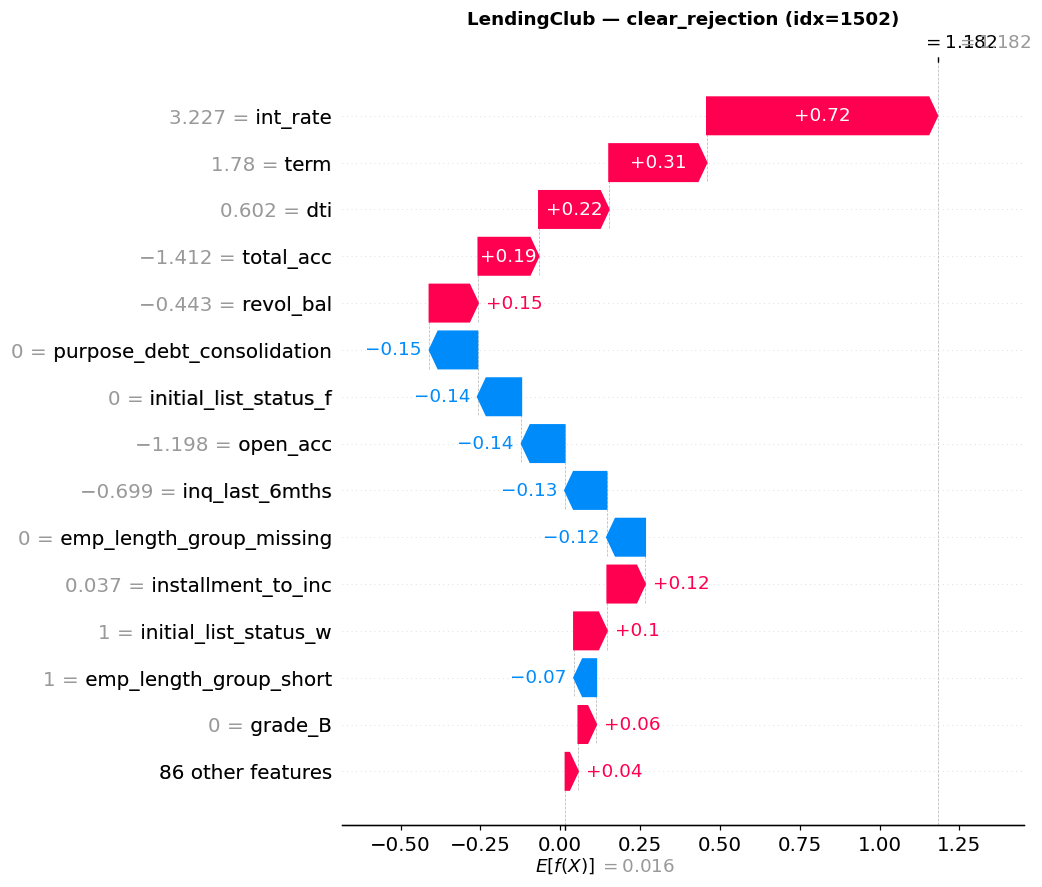

  Saved → /content/drive/MyDrive/CreditRisk_Wk6/figures/lendingclub_waterfall_borderline_2550.png


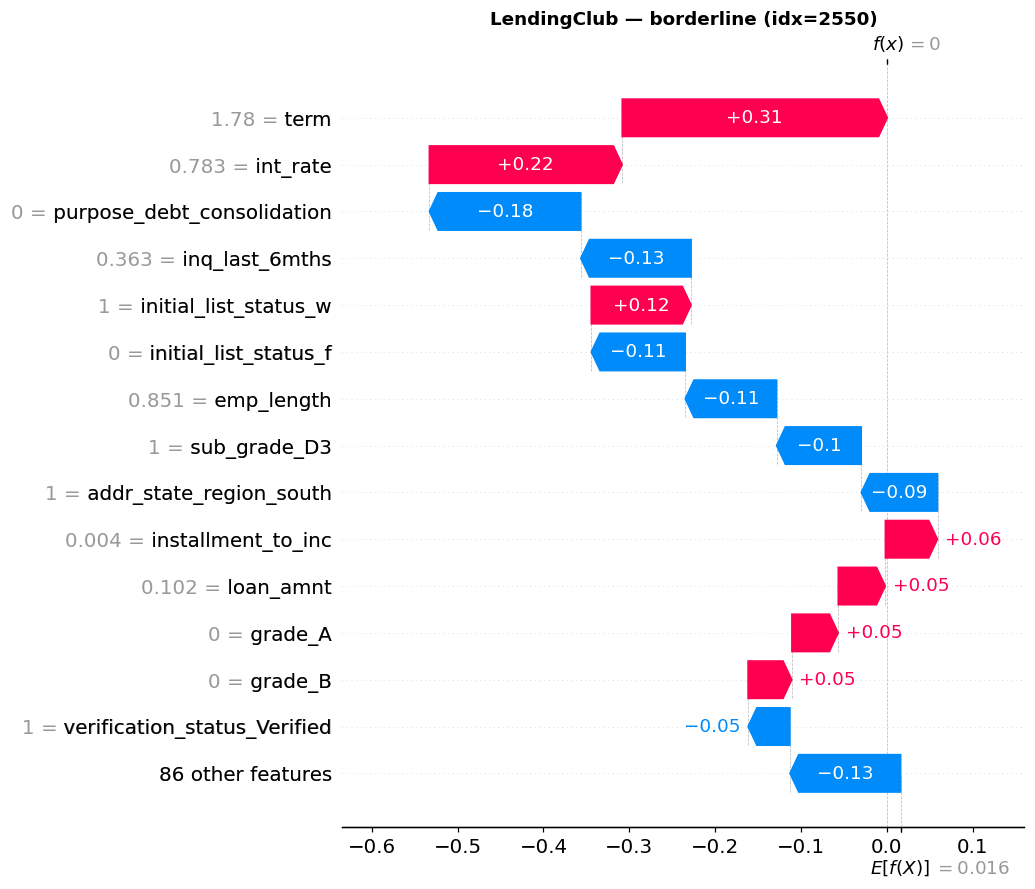

In [21]:
for kind, idxs in cases_lc.items():
    for idx in idxs:
        if name_lc == 'Logistic Regression':
            ev = float(np.array(explainer_lc.expected_value).flatten()[0])
        else:
            ev_arr = np.array(explainer_lc.expected_value).flatten()
            ev = float(ev_arr[1] if len(ev_arr) > 1 else ev_arr[0])
        explanation = shap.Explanation(
            values=sv_lc_full[idx],
            base_values=ev,
            data=X_te2_sample.iloc[idx].values,
            feature_names=X_te2_sample.columns.tolist())
        plt.figure()
        shap.plots.waterfall(explanation, max_display=15, show=False)
        plt.title(f'LendingClub — {kind} (idx={idx})', fontsize=12, weight='bold')
        save_fig(f'lendingclub_waterfall_{kind}_{idx}')
        plt.show()

## 2.5 Domain Validation — LendingClub

In [27]:
print('═══ LendingClub — Top 10 Features by Mean |SHAP| ═══\n')
top10_lc = mean_abs_lc.nlargest(10)
for rank, (feat, val) in enumerate(top10_lc.items(), 1):
    print(f'  {rank:2d}. {feat:40s} {val:.4f}')

print('\n📋 Domain check:')
print("   - Does grade rank high?                        Expected: YES (LCs own risk grade)")
print('   - Does dti (debt-to-income) rank high?        Expected: YES')
print('   - Does fico_range_low rank high?              Expected: YES (FICO is gold standard)')
print("   - Does grade rank high?                        Expected: YES (LC's own risk grade)")
print('   - Any counterintuitive features?               FLAG FOR DISCUSSION')

═══ LendingClub — Top 10 Features by Mean |SHAP| ═══

   1. int_rate                                 0.3178
   2. term                                     0.1738
   3. mort_acc                                 0.1686
   4. purpose_debt_consolidation               0.1250
   5. inq_last_6mths                           0.1242
   6. grade_A                                  0.1236
   7. dti                                      0.1171
   8. open_acc                                 0.1163
   9. installment_to_inc                       0.1142
  10. initial_list_status_w                    0.1067

📋 Domain check:
   - Does grade rank high?                        Expected: YES (LCs own risk grade)
   - Does dti (debt-to-income) rank high?        Expected: YES
   - Does fico_range_low rank high?              Expected: YES (FICO is gold standard)
   - Does grade rank high?                        Expected: YES (LC's own risk grade)
   - Any counterintuitive features?               FLAG FOR DISCUSSIO

## 2.6 Save SHAP Values

In [28]:
out_lc = f'{SHAP_DIR}/lendingclub_shap.joblib'
joblib.dump({
    'shap_values_full'   : sv_lc_full,
    'shap_values_sample' : shap_vals_lc,
    'X_sample'           : X_lc_sample,
    'X_test_sample'      : X_te2_sample,
    'y_test_sample'      : y_te2_sample,
    'expected_value'     : explainer_lc.expected_value,
    'feature_names'      : X_te2.columns.tolist(),
    'model_name'         : name_lc,
    'top_features'       : top10_lc.to_dict(),
    'representative_cases': cases_lc,
}, out_lc)
print(f'Saved → {out_lc}  ({os.path.getsize(out_lc)/1e6:.2f} MB)')

Saved → /content/drive/MyDrive/CreditRisk_Wk6/shap_values/lendingclub_shap.joblib  (8.50 MB)


---
# 3 — Credit Card Fraud

## 3.1 Load Best Model & Data
For Fraud, the test set is large (~57k rows) but fraud cases are very rare
(~0.17%). We sample stratified — keeping all fraud cases plus a random
subset of genuine ones — so SHAP captures fraud-specific patterns.

In [29]:
X_tr3, X_va3, X_te3, y_tr3, y_va3, y_te3 = load_splits('fraud')
model_f, name_f, tag_f = load_best_model('fraud')

from sklearn.metrics import roc_auc_score
auc_check = roc_auc_score(y_te3, model_f.predict_proba(X_te3)[:,1])
print(f'\n[sanity] test AUC: {auc_check:.4f}  (Week 5 registry: {BEST["fraud"]["test_roc_auc"]:.4f})')

[fraud] loaded XGBoost from /content/drive/MyDrive/CreditRisk_Wk4/models/fraud_xgb.joblib

[sanity] test AUC: 0.9825  (Week 5 registry: 0.9825)


## 3.2 Stratified Sample for SHAP

In [33]:
# Take ALL fraud cases + a random sample of genuine cases (≈ 2000 total)
X_te3_reset = X_te3.reset_index(drop=True)
y_te3_reset = y_te3.reset_index(drop=True)

fraud_idx   = y_te3_reset[y_te3_reset == 1].index
genuine_idx = y_te3_reset[y_te3_reset == 0].sample(n=2000, random_state=RANDOM_STATE).index

sample_idx  = fraud_idx.union(genuine_idx)
X_f_strat   = X_te3_reset.loc[sample_idx].reset_index(drop=True)
y_f_strat   = y_te3_reset.loc[sample_idx].reset_index(drop=True)

print(f'Stratified sample: {len(X_f_strat)} rows '
      f'({y_f_strat.sum()} fraud, {(y_f_strat==0).sum()} genuine)')

bg_f = shap.sample(X_tr3, 100, random_state=RANDOM_STATE)
explainer_f = make_explainer(model_f, name_f, bg_f)

shap_vals_f, _ = compute_shap_values(explainer_f, X_f_strat, name_f, max_rows=len(X_f_strat))
print(f'  shap_values shape: {shap_vals_f.shape}')

Stratified sample: 2074 rows (74 fraud, 2000 genuine)
  Computing SHAP on all 2074 rows
  shap_values shape: (2074, 36)


## 3.3 Global Explanations — Fraud

  Saved → /content/drive/MyDrive/CreditRisk_Wk6/figures/fraud_beeswarm.png


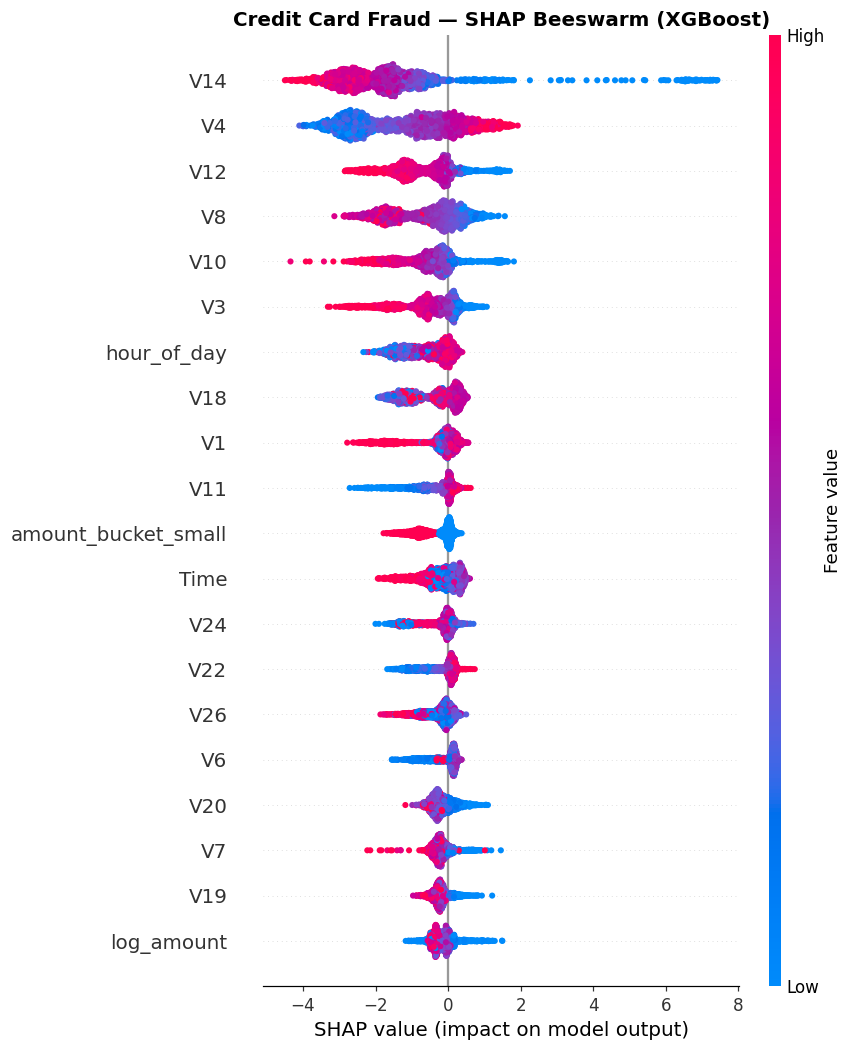

In [34]:
shap.summary_plot(shap_vals_f, X_f_strat, max_display=20, show=False)
plt.title(f'Credit Card Fraud — SHAP Beeswarm ({name_f})', fontsize=13, weight='bold')
save_fig('fraud_beeswarm')
plt.show()

  Saved → /content/drive/MyDrive/CreditRisk_Wk6/figures/fraud_bar.png


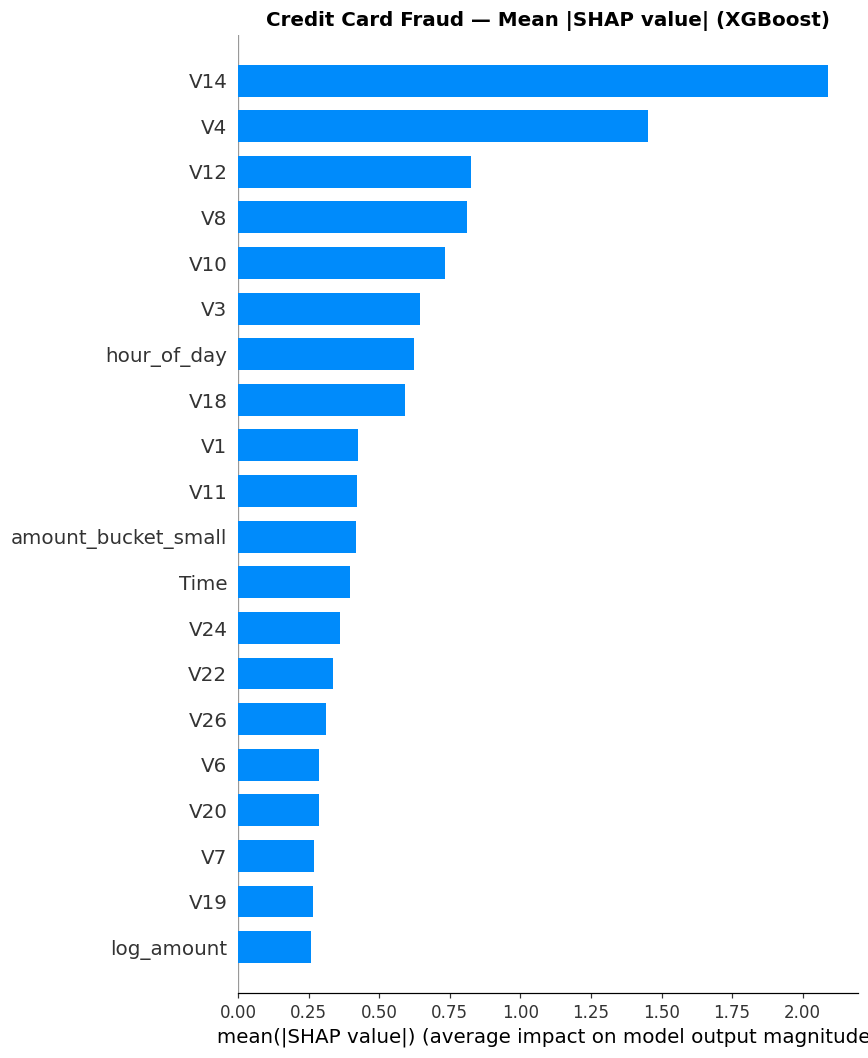

In [35]:
shap.summary_plot(shap_vals_f, X_f_strat, plot_type='bar', max_display=20, show=False)
plt.title(f'Credit Card Fraud — Mean |SHAP value| ({name_f})', fontsize=13, weight='bold')
save_fig('fraud_bar')
plt.show()

Top 5 features (Fraud): ['V14', 'V4', 'V12', 'V8', 'V10']
  Saved → /content/drive/MyDrive/CreditRisk_Wk6/figures/fraud_dependence_top5.png


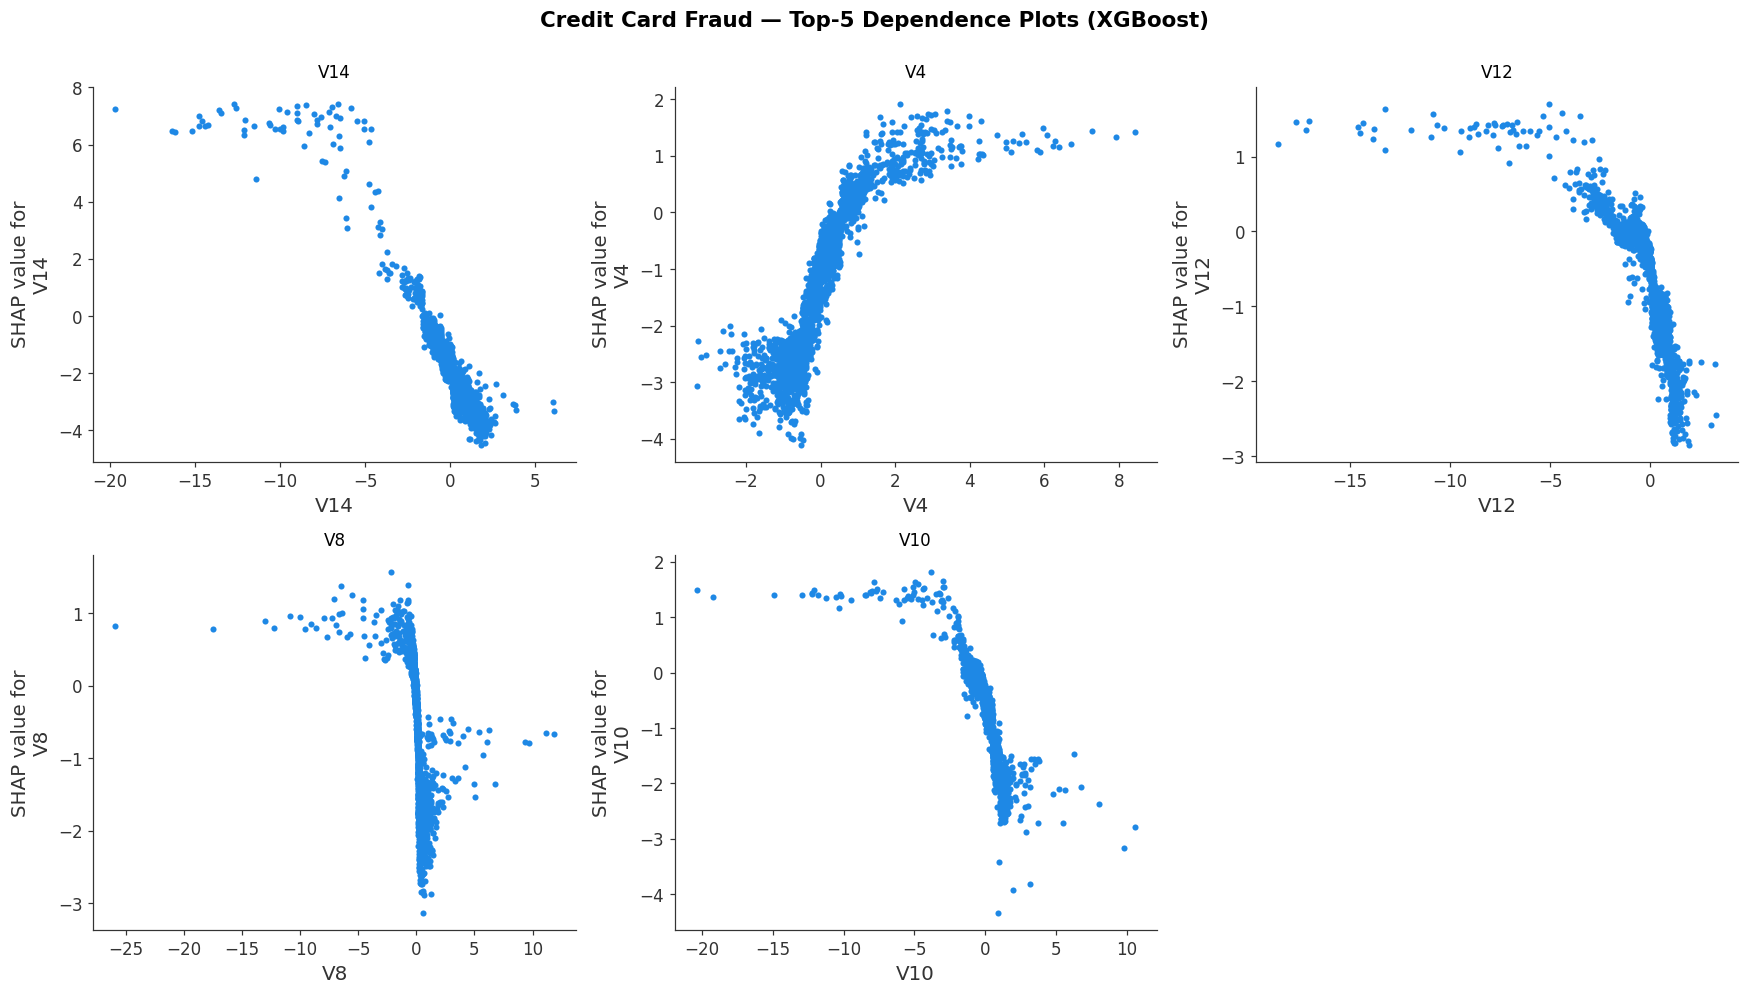

In [36]:
mean_abs_f = pd.Series(np.abs(shap_vals_f).mean(axis=0), index=X_f_strat.columns)
top5_f = mean_abs_f.nlargest(5).index.tolist()
print(f'Top 5 features (Fraud): {top5_f}')

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, feat in enumerate(top5_f):
    shap.dependence_plot(feat, shap_vals_f, X_f_strat,
                         ax=axes[i], show=False, interaction_index=None)
    axes[i].set_title(f'{feat}', fontsize=11)
axes[5].axis('off')
plt.suptitle(f'Credit Card Fraud — Top-5 Dependence Plots ({name_f})',
             fontsize=14, weight='bold', y=1.00)
plt.tight_layout()
save_fig('fraud_dependence_top5')
plt.show()

## 3.4 Local Explanations — Fraud

In [37]:
cases_f = pick_representative_cases(model_f, X_f_strat, y_f_strat, n_per_kind=1)

print('Selected cases:')
for kind, idxs in cases_f.items():
    for idx in idxs:
        prob = model_f.predict_proba(X_f_strat.iloc[[idx]])[0, 1]
        actual = y_f_strat.iloc[idx]
        print(f'  {kind:18s} idx={idx:5d}  P(fraud)={prob:.4f}  actual={actual}')

Selected cases:
  clear_approval     idx= 1911  P(fraud)=0.0000  actual=0
  clear_rejection    idx= 1347  P(fraud)=1.0000  actual=1
  borderline         idx= 1706  P(fraud)=0.5103  actual=0


  Saved → /content/drive/MyDrive/CreditRisk_Wk6/figures/fraud_waterfall_clear_approval_1911.png


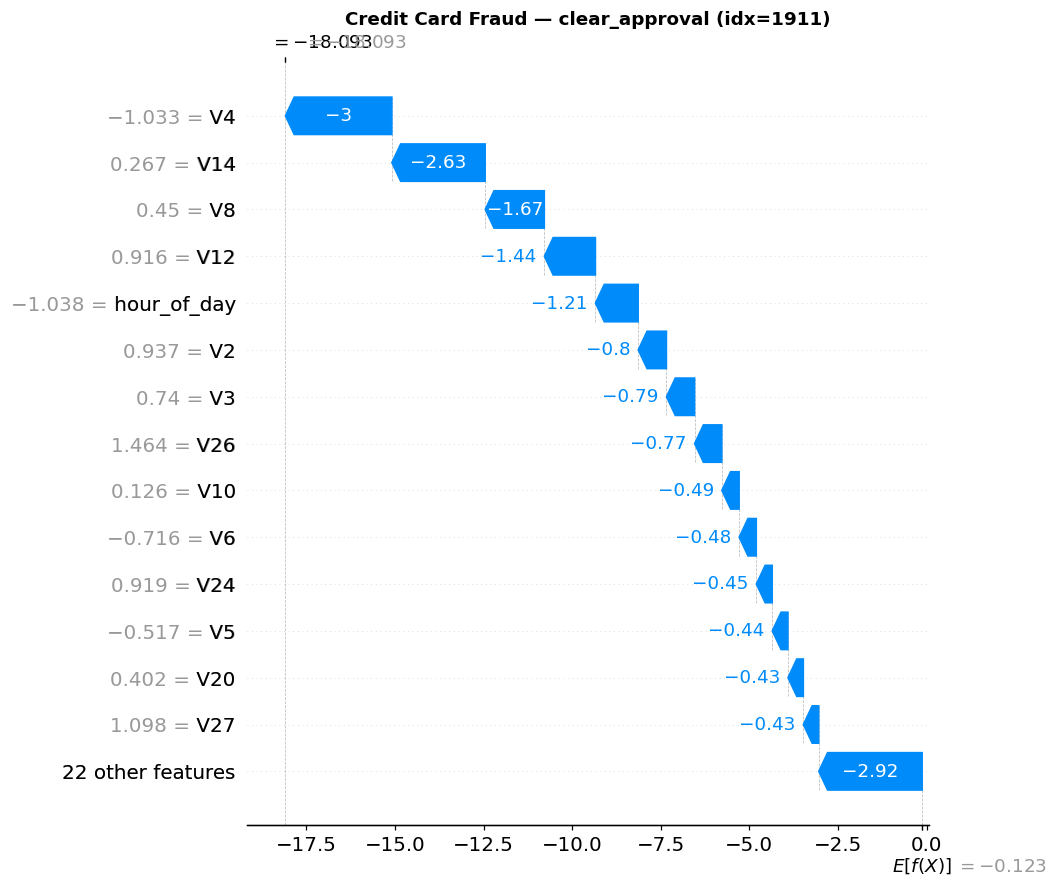

  Saved → /content/drive/MyDrive/CreditRisk_Wk6/figures/fraud_waterfall_clear_rejection_1347.png


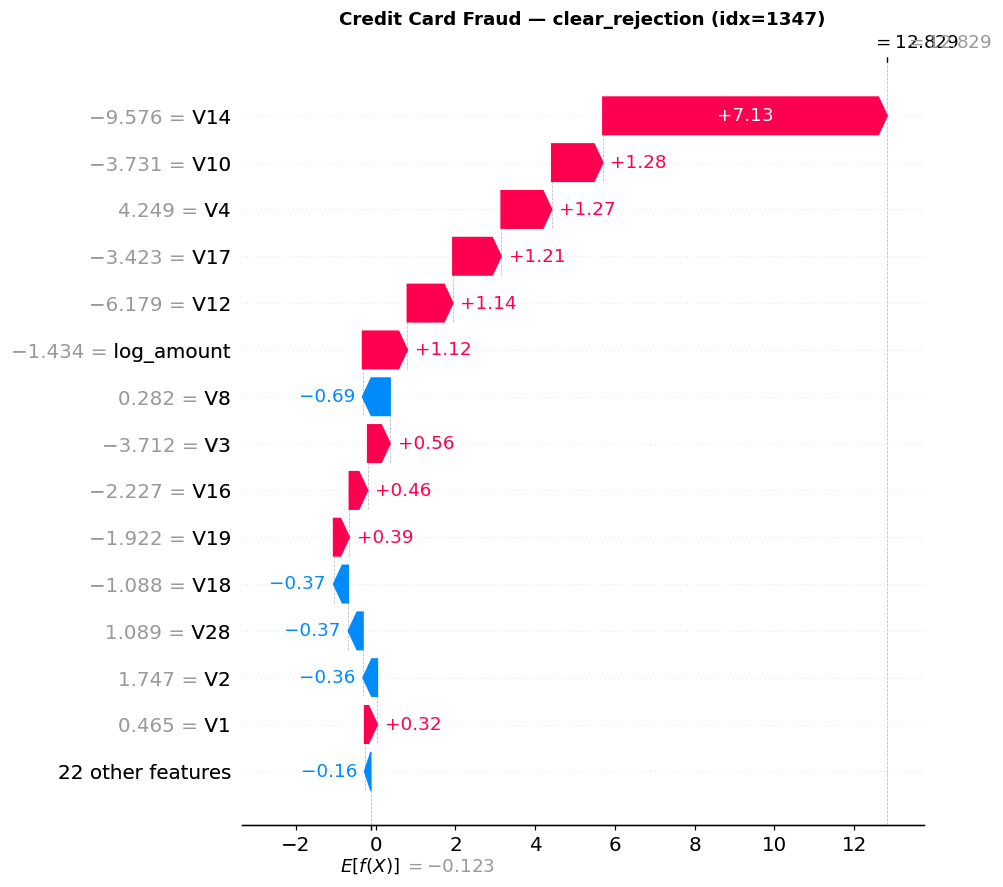

  Saved → /content/drive/MyDrive/CreditRisk_Wk6/figures/fraud_waterfall_borderline_1706.png


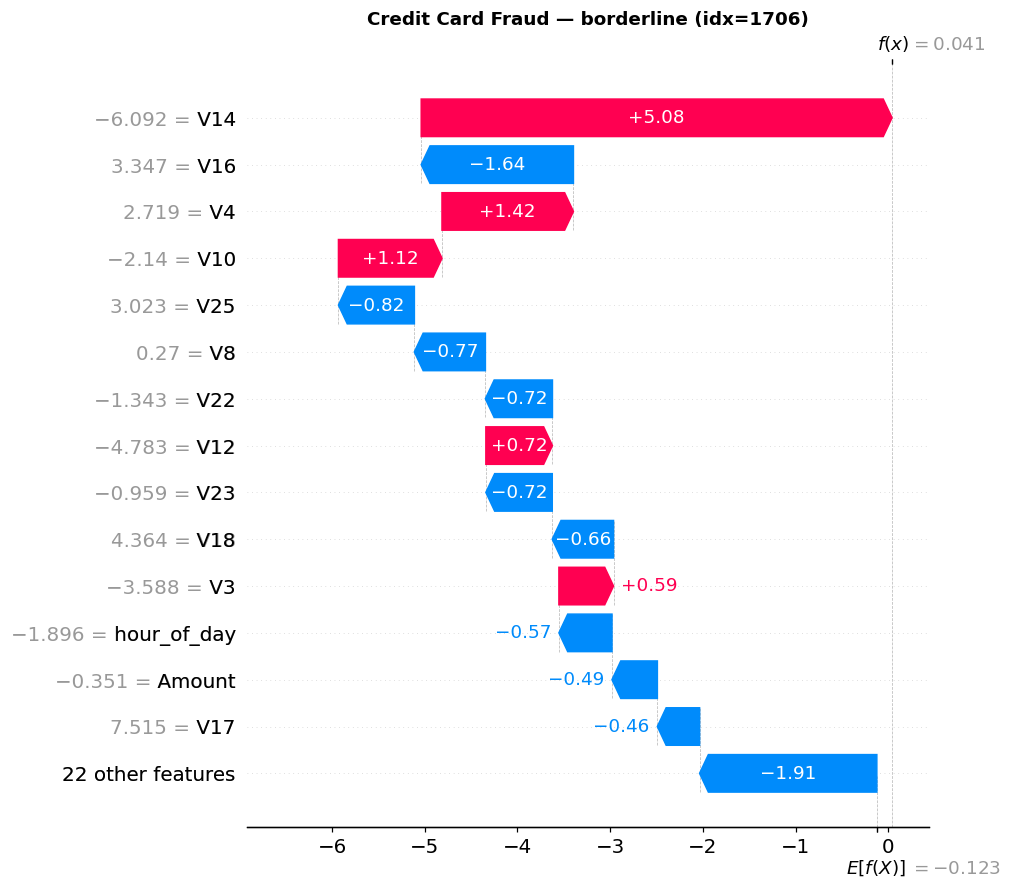

In [38]:
for kind, idxs in cases_f.items():
    for idx in idxs:
        if name_f == 'Logistic Regression':
            ev = float(np.array(explainer_f.expected_value).flatten()[0])
        else:
            ev_arr = np.array(explainer_f.expected_value).flatten()
            ev = float(ev_arr[1] if len(ev_arr) > 1 else ev_arr[0])
        explanation = shap.Explanation(
            values=shap_vals_f[idx],
            base_values=ev,
            data=X_f_strat.iloc[idx].values,
            feature_names=X_f_strat.columns.tolist())
        plt.figure()
        shap.plots.waterfall(explanation, max_display=15, show=False)
        plt.title(f'Credit Card Fraud — {kind} (idx={idx})', fontsize=12, weight='bold')
        save_fig(f'fraud_waterfall_{kind}_{idx}')
        plt.show()

## 3.5 Domain Validation — Fraud
V1–V28 are PCA-anonymised, so domain validation is limited. The interesting
check is whether **engineered features** (`log_amount`, `hour_of_day`, etc.)
appear among the top contributors — that would justify the feature engineering.

In [39]:
print('═══ Credit Card Fraud — Top 10 Features by Mean |SHAP| ═══\n')
top10_f = mean_abs_f.nlargest(10)
for rank, (feat, val) in enumerate(top10_f.items(), 1):
    is_engineered = feat in ['log_amount','hour_of_day','day','high_amount','zero_amount']
    marker = ' ← engineered' if is_engineered else ''
    print(f'  {rank:2d}. {feat:25s} {val:.4f}{marker}')

print('\n📋 Domain check:')
print('   - Do V14, V12, V10, V17 dominate?  Expected: YES (well-known fraud literature)')
print('   - Do any engineered features appear?  If YES → feature engineering paid off')

═══ Credit Card Fraud — Top 10 Features by Mean |SHAP| ═══

   1. V14                       2.0913
   2. V4                        1.4520
   3. V12                       0.8264
   4. V8                        0.8109
   5. V10                       0.7324
   6. V3                        0.6434
   7. hour_of_day               0.6242 ← engineered
   8. V18                       0.5919
   9. V1                        0.4233
  10. V11                       0.4207

📋 Domain check:
   - Do V14, V12, V10, V17 dominate?  Expected: YES (well-known fraud literature)
   - Do any engineered features appear?  If YES → feature engineering paid off


## 3.6 Save SHAP Values

In [40]:
out_f = f'{SHAP_DIR}/fraud_shap.joblib'
joblib.dump({
    'shap_values_full'   : shap_vals_f,
    'X_test_sample'      : X_f_strat,
    'y_test_sample'      : y_f_strat,
    'expected_value'     : explainer_f.expected_value,
    'feature_names'      : X_te3.columns.tolist(),
    'model_name'         : name_f,
    'top_features'       : top10_f.to_dict(),
    'representative_cases': cases_f,
}, out_f)
print(f'Saved → {out_f}  ({os.path.getsize(out_f)/1e6:.2f} MB)')

Saved → /content/drive/MyDrive/CreditRisk_Wk6/shap_values/fraud_shap.joblib  (0.93 MB)


---
# 4 — Week 6 Summary

In [41]:
print('═'*70)
print('     WEEK 6 — SHAP INTEGRATION COMPLETE')
print('═'*70)

summary = pd.DataFrame({
    'Dataset'         : ['German Credit', 'LendingClub', 'Credit Card Fraud'],
    'Best model'      : [name_g, name_lc, name_f],
    'Top feature'     : [top10_g.index[0], top10_lc.index[0], top10_f.index[0]],
    'Top-1 |SHAP|'    : [round(top10_g.iloc[0],4),
                         round(top10_lc.iloc[0],4),
                         round(top10_f.iloc[0],4)],
    'SHAP rows'       : [len(X_te1_idx), len(X_te2_sample), len(X_f_strat)],
})
display(summary)

print('\nSaved files (used by Weeks 7, 8, 9):')
for fname in ['german_shap.joblib','lendingclub_shap.joblib','fraud_shap.joblib']:
    p = f'{SHAP_DIR}/{fname}'
    if os.path.exists(p):
        print(f'  ✅ {fname}  ({os.path.getsize(p)/1e6:.2f} MB)')

print(f'\nFigures saved to: {FIGURES_DIR}')
print(f'  → {len([f for f in os.listdir(FIGURES_DIR) if f.endswith(".png")])} PNG files')

print('\nNEXT — Week 7: LIME + Counterfactuals')
print('  - LIME explanations on the same representative cases (cross-check SHAP)')
print('  - SHAP-vs-LIME consistency analysis (target: ≥ 80% top-5 agreement)')
print('  - DiCE counterfactuals for the rejected applicants')
print('═'*70)

══════════════════════════════════════════════════════════════════════
     WEEK 6 — SHAP INTEGRATION COMPLETE
══════════════════════════════════════════════════════════════════════


,Dataset,Best model,Top feature,Top-1 |SHAP|,SHAP rows
0,German Credit,Logistic Regression,checking_account_A14,0.4258,150
1,LendingClub,XGBoost,int_rate,0.3178,5000
2,Credit Card Fraud,XGBoost,V14,2.0913,2074



Saved files (used by Weeks 7, 8, 9):
  ✅ german_shap.joblib  (0.30 MB)
  ✅ lendingclub_shap.joblib  (8.50 MB)
  ✅ fraud_shap.joblib  (0.93 MB)

Figures saved to: /content/drive/MyDrive/CreditRisk_Wk6/figures
  → 18 PNG files

NEXT — Week 7: LIME + Counterfactuals
  - LIME explanations on the same representative cases (cross-check SHAP)
  - SHAP-vs-LIME consistency analysis (target: ≥ 80% top-5 agreement)
  - DiCE counterfactuals for the rejected applicants
══════════════════════════════════════════════════════════════════════
